# Análisis Exploratorio de Datos (EDA): Colombia EVA

El propósito de este trabajo es evaluar la idoneidad del dataset para aprendizaje automático, identificando su contenido, los principales problemas de calidad, las transformaciones necesarias y su viabilidad para entrenamiento de modelos supervisados.

La pregunta central del informe es si el dataset puede dejarse listo para modelado de clasificación o regresión cumpliendo criterios técnicos y metodológicos.

**Materia:** Programación Avanzada

**Profesor:** Jaime Alberto Vergara Tejada

**Estudiante:** Diego Alejandro Ríos Vásquez

**Fuente de datos:** Datos.gov.co (API Socrata SODA)

**Dataset ID:** 2pnw-mmge

**Endpoint:** https://www.datos.gov.co/api/v3/views/2pnw-mmge/query.json


## Resumen Ejecutivo

Este informe evalúa la viabilidad del dataset **Colombia EVA** para aprendizaje automático con base en criterios de calidad, estructura y capacidad predictiva. Se trabajó con 5000 registros y 17 variables, con una tipificación que permitió identificar 7 variables numéricas útiles para modelado, superando el mínimo exigido por la rúbrica.

La variable objetivo definida fue `ciclo_de_cultivo`, configurando un problema de clasificación multiclase con tres categorías. En calidad de datos se observó un faltante relevante en `rendimiento_t_ha` (7.9%) y un faltante puntual en `municipio` (0.02%), sin duplicados exactos en la muestra analizada.

Las distribuciones evidenciaron asimetrías y valores extremos en variables productivas, lo que respalda la necesidad de transformaciones y tratamiento robusto de outliers. El análisis de correlación mostró relaciones altas que sugieren posibles redundancias, y la evaluación frente a la variable objetivo confirmó capacidad de separación en variables numéricas clave.

El balance de clases mostró desproporción marcada (ratio mayoritaria/minoritaria de 19.47), por lo que el entrenamiento debe contemplar partición estratificada, métricas robustas por clase y estrategias de remuestreo o ponderación.

El dataset cumple los criterios de la entrega y es apto para continuar a la fase de entrenamiento, siempre que se mantengan las decisiones de preprocesamiento documentadas en este informe.

## 0. Preparación técnica del entorno

In [144]:
# Instala sodapy solo si no está disponible en el entorno
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('sodapy') is None:
    print('Instalando sodapy...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'sodapy', '-q'])
    print('sodapy instalado correctamente.')
else:
    print('sodapy ya está disponible.')

sodapy ya está disponible.


In [145]:
import sys
import os
import warnings
from datetime import datetime

# Evita conflictos por archivos locales que sombreen librerías (por ejemplo, pandas.py)
cwd = os.getcwd()
removed_paths = []

for p in (cwd, ''):
    if p in sys.path:
        sys.path.remove(p)
        removed_paths.append(p)

if 'pandas' in sys.modules:
    del sys.modules['pandas']

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sodapy import Socrata

# Restaura rutas removidas temporalmente
for p in reversed(removed_paths):
    sys.path.insert(0, p)

warnings.filterwarnings('ignore')

# Configuración visual base para todas las gráficas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

print('Librerías importadas correctamente.')
print(f'Marca de tiempo de ejecución: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Librerías importadas correctamente.
Marca de tiempo de ejecución: 2026-04-24 14:53:16


## 0.1 Fuente de datos y conexión API

In [146]:
# Configuración para API Socrata (Datos.gov.co)
# Documentación: https://datos.gov.co/

from pathlib import Path

DOMAIN = 'datos.gov.co'
DATASET_ID = '2pnw-mmge'  # Dataset oficial Colombia EVA

# Carga automática de variables desde .env
env_path = Path('.env')
loaded_from_env = False

if env_path.exists():
    try:
        from dotenv import load_dotenv
        load_dotenv(dotenv_path=env_path, override=False)
        loaded_from_env = True
    except Exception:
        # Fallback sin dependencias externas
        for line in env_path.read_text(encoding='utf-8').splitlines():
            line = line.strip()
            if not line or line.startswith('#') or '=' not in line:
                continue
            key, value = line.split('=', 1)
            key = key.strip()
            value = value.strip().strip('"').strip("'")
            os.environ.setdefault(key, value)
        loaded_from_env = True

# Variables de entorno esperadas:
# - DATOSABIERTOS_API_KEY
# - DATOSABIERTOS_API_SECRET
# - DATOSABIERTOS_APP_TOKEN (opcional; si no existe, se usa API_KEY como token)
API_KEY_ID = os.environ.get('DATOSABIERTOS_API_KEY')
API_SECRET = os.environ.get('DATOSABIERTOS_API_SECRET')
APP_TOKEN = os.environ.get('DATOSABIERTOS_APP_TOKEN') or API_KEY_ID

if APP_TOKEN and API_SECRET:
    auth_msg = 'Configurada (API Key + Secret)'
elif APP_TOKEN:
    auth_msg = 'Configurada (solo token/app token)'
else:
    auth_msg = 'Sin credenciales (modo publico; puede tener limites de tasa)'

print('Configuracion de Datos.gov.co:')
print(f'  Dominio: {DOMAIN}')
print(f'  Dataset ID: {DATASET_ID}')
print(f'  Dataset: Colombia EVA')
print(f'  .env cargado: {"Si" if loaded_from_env else "No"}')
print(f'  Autenticacion: {auth_msg}')
print(f'  API Key detectada: {"Si" if API_KEY_ID else "No"}')
print(f'  API Secret detectado: {"Si" if API_SECRET else "No"}')

Configuracion de Datos.gov.co:
  Dominio: datos.gov.co
  Dataset ID: 2pnw-mmge
  Dataset: Colombia EVA
  .env cargado: Si
  Autenticacion: Configurada (API Key + Secret)
  API Key detectada: Si
  API Secret detectado: Si


### Nota metodológica sobre la fuente de datos

La fuente de información corresponde al portal oficial de datos abiertos de Colombia y se consulta mediante API SODA. El recurso seleccionado fue validado por su disponibilidad pública, volumen y potencial analítico para tareas de aprendizaje automático supervisado.

La consulta se reproduce usando el identificador `2pnw-mmge`, con extracción de registros desde la API y conversión posterior a estructura tabular para análisis estadístico.

```python
results = client.get('2pnw-mmge', limit=5000)
df = pd.DataFrame.from_records(results)
```

## 3. Carga de datos

In [147]:
def fetch_data_from_soda(domain, dataset_id, app_token=None, limit=5000, batch_size=1000):
    """Obtiene datos desde Datos.gov.co usando paginación por offset."""
    def _request_page(token, page_limit, page_offset):
        client = Socrata(domain, token, timeout=60)
        return client.get(dataset_id, limit=page_limit, offset=page_offset)

    def _fetch_paginated(token):
        collected = []
        offset = 0
        target = limit if (limit is not None and limit > 0) else None

        while True:
            page_limit = batch_size
            if target is not None:
                remaining = target - len(collected)
                if remaining <= 0:
                    break
                page_limit = min(batch_size, remaining)

            page = _request_page(token, page_limit, offset)
            if not page:
                break

            collected.extend(page)
            offset += len(page)
            print(f'  Lote recibido: {len(page):,} filas (acumulado: {len(collected):,})')

            if len(page) < page_limit:
                break

        return collected

    try:
        print(f'Conectando a {domain}...')
        print(f'Consultando dataset {dataset_id} con paginacion...')
        print(f'  Parametros: limit={limit}, batch_size={batch_size}')
        results = _fetch_paginated(app_token)

        if not results:
            print('Error: la consulta retorno resultados vacios.')
            return None

        df = pd.DataFrame.from_records(results)
        print('Datos cargados correctamente.')
        print(f'  Tamano: {df.shape[0]:,} filas x {df.shape[1]} columnas')
        return df

    except Exception as e:
        msg = str(e)
        if app_token and ('Invalid app_token' in msg or '403' in msg):
            try:
                print('Token invalido o rechazado. Reintentando sin token...')
                results = _fetch_paginated(None)
                if not results:
                    print('Error: la consulta sin token retorno resultados vacios.')
                    return None
                df = pd.DataFrame.from_records(results)
                print('Datos cargados correctamente en modo publico.')
                print(f'  Tamano: {df.shape[0]:,} filas x {df.shape[1]} columnas')
                return df
            except Exception as e2:
                print(f'Error al reintentar sin token: {str(e2)}')
                return None

        print(f'Error al obtener datos: {msg}')
        print('\nSugerencias de validacion:')
        print(f'  1. Verifica DATASET_ID (actual: {dataset_id})')
        print('  2. Verifica conexion a internet')
        print('  3. Revisa disponibilidad del portal datos.gov.co')
        print('  4. Si usas token, valida que sea correcto')
        return None

In [148]:
# Carga principal del dataset (prioriza CSV completo local, con fallback a API)
print('Iniciando carga de datos...\n')

import re
import unicodedata

def normalize_header(text):
    s = str(text).replace('\n', ' ').strip().lower()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = re.sub(r'[^a-z0-9]+', ' ', s).strip()
    s = re.sub(r'\s+', ' ', s)
    return s

def standardize_eva_columns(df_input):
    target_map = {
        'cod dep': 'c_d_dep',
        'departamento': 'departamento',
        'cod mun': 'c_d_mun',
        'municipio': 'municipio',
        'grupo de cultivo': 'grupo_de_cultivo',
        'subgrupo de cultivo': 'subgrupo_de_cultivo',
        'cultivo': 'cultivo',
        'desagregacion regional y o sistema productivo': 'desagregaci_n_regional_y',
        'ano': 'a_o',
        'periodo': 'periodo',
        'area sembrada ha': 'rea_sembrada_ha',
        'area cosechada ha': 'rea_cosechada_ha',
        'produccion t': 'producci_n_t',
        'rendimiento t ha': 'rendimiento_t_ha',
        'estado fisico produccion': 'estado_fisico_produccion',
        'nombre cientifico': 'nombre_cientifico',
        'ciclo de cultivo': 'ciclo_de_cultivo'
    }

    rename_map = {}
    for col in df_input.columns:
        normalized = normalize_header(col)
        if normalized in target_map:
            rename_map[col] = target_map[normalized]

    df_out = df_input.rename(columns=rename_map).copy()
    return df_out, rename_map

csv_path = Path('data') / 'Evaluaciones_Agropecuarias_Municipales_EVA.csv'
df = None
source_used = None

if csv_path.exists():
    try:
        print(f'Cargando dataset completo desde CSV local: {csv_path}')
        df = pd.read_csv(csv_path)
        source_used = 'CSV local completo'
        print('Carga desde CSV completada correctamente.')
    except Exception as e:
        print(f'No fue posible cargar el CSV local: {str(e)}')
        print('Se intentará cargar por API como respaldo.\n')

if df is None:
    LOAD_LIMIT = 5000
    BATCH_SIZE = 1000
    print(f'Se solicitarán hasta {LOAD_LIMIT:,} registros al API usando lotes de {BATCH_SIZE:,}.\n')

    df = fetch_data_from_soda(
        domain=DOMAIN,
        dataset_id=DATASET_ID,
        app_token=APP_TOKEN,
        limit=LOAD_LIMIT,
        batch_size=BATCH_SIZE
    )
    if df is not None and len(df) > 0:
        source_used = 'API SODA (muestra operativa de 5000)'

if df is not None and len(df) > 0:
    df, renamed_columns = standardize_eva_columns(df)
    print(f'\nColumnas estandarizadas: {len(renamed_columns)}')
    if renamed_columns:
        print('- Se homologaron encabezados para compatibilidad API/CSV.')

    print('\nResumen inicial del dataset:')
    print(f'  Fuente utilizada: {source_used}')
    print(f'  Total de registros cargados: {df.shape[0]:,}')
    print(f'  Total de columnas: {df.shape[1]}')
    print('\nPrimeras filas:')
    display(df.head())
else:
    print('\nNo se logró cargar la data ni desde CSV local ni desde API.')
    print('Verifica la ruta del archivo o la conectividad hacia datos.gov.co.')

Iniciando carga de datos...

Cargando dataset completo desde CSV local: data\Evaluaciones_Agropecuarias_Municipales_EVA.csv
Carga desde CSV completada correctamente.

Columnas estandarizadas: 17
- Se homologaron encabezados para compatibilidad API/CSV.

Resumen inicial del dataset:
  Fuente utilizada: CSV local completo
  Total de registros cargados: 206,068
  Total de columnas: 17

Primeras filas:


,c_d_dep,departamento,c_d_mun,municipio,grupo_de_cultivo,subgrupo_de_cultivo,cultivo,desagregaci_n_regional_y,a_o,periodo,rea_sembrada_ha,rea_cosechada_ha,producci_n_t,rendimiento_t_ha,estado_fisico_produccion,nombre_cientifico,ciclo_de_cultivo
0,15,BOYACA,"15,114",BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,1,1,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,"25,754",SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,82,80,"1,440",18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,"25,214",COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,2,2,26,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
3,54,NORTE DE SANTANDER,"54,405",LOS PATIOS,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,3,3,48,16.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
4,54,NORTE DE SANTANDER,"54,518",PAMPLONA,HORTALIZAS,ACELGA,ACELGA,ACELGA,"2,006",2006B,1,1,5,10.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO


### 3.1 Verificación de cumplimiento de requisitos de la entrega

En esta sección se estandarizan tipos de datos para validar formalmente el cumplimiento de la rúbrica. La verificación contempla tres aspectos: disponibilidad de al menos cinco variables numéricas, existencia de una variable objetivo apta para clasificación o regresión y tamaño muestral suficiente para análisis (mínimo recomendado de mil registros).

In [149]:
# Estandarización de datos y verificación de requisitos (Sección 3.1)
if df is not None and len(df) > 0:
    # 1) Estandarización numérica
    numeric_candidates = [
        'c_d_dep', 'c_d_mun', 'a_o',
        'rea_sembrada_ha', 'rea_cosechada_ha',
        'producci_n_t', 'rendimiento_t_ha'
    ]

    for col in numeric_candidates:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 2) Estandarización básica de texto en variables categóricas
    object_cols = df.select_dtypes(include='object').columns.tolist()
    cleaned_cells = 0
    for col in object_cols:
        s = df[col].astype(str)
        original = s.copy()
        s = s.str.strip().str.replace(r'\s+', ' ', regex=True)
        df[col] = s.where(df[col].notna(), np.nan)
        cleaned_cells += int((original != s).sum())

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print('Chequeo de requisitos del dataset:')
    print(f'- Registros cargados: {len(df):,}')
    print(f'- Variables numéricas detectadas: {len(numeric_cols)}')
    print(f'  {numeric_cols}')
    print(f'- Celdas categóricas estandarizadas (trim/espacios): {cleaned_cells:,}')

    suggested_target = 'ciclo_de_cultivo' if 'ciclo_de_cultivo' in df.columns else None
    if suggested_target:
        n_classes = df[suggested_target].nunique(dropna=True)
        print(f'- Variable objetivo sugerida: {suggested_target} (clasificación, {n_classes} clases)')
    else:
        print('- No se encontró una variable objetivo categórica obvia automáticamente.')

    cumple_numericas = len(numeric_cols) >= 5
    cumple_registros_rubrica = len(df) >= 1000
    cumple_registros_operativo = len(df) >= 5000
    cumple_objetivo = suggested_target is not None

    txt_num = 'Sí' if cumple_numericas else 'No'
    txt_rubrica = 'Sí' if cumple_registros_rubrica else 'No'
    txt_operativo = 'Sí' if cumple_registros_operativo else 'No'
    txt_obj = 'Sí' if cumple_objetivo else 'No'

    print('\nResultado de cumplimiento:')
    print(f'- Cumple >= 5 numéricas: {txt_num}')
    print(f'- Cumple rúbrica (>= 1000 registros): {txt_rubrica}')
    print(f'- Cumple objetivo operativo (>= 5000 registros): {txt_operativo}')
    print(f'- Tiene objetivo para modelado: {txt_obj}')

    if cumple_numericas and cumple_registros_rubrica and cumple_objetivo:
        print('\nConclusión 3.1: el dataset es apto para análisis y modelado, con preprocesamiento documentado.')
    else:
        print('\nConclusión 3.1: el dataset aún no cumple totalmente; se requieren ajustes adicionales.')
else:
    print('No hay datos cargados. Ejecuta primero la sección de carga desde API.')

Chequeo de requisitos del dataset:
- Registros cargados: 206,068
- Variables numéricas detectadas: 7
  ['c_d_dep', 'c_d_mun', 'a_o', 'rea_sembrada_ha', 'rea_cosechada_ha', 'producci_n_t', 'rendimiento_t_ha']
- Celdas categóricas estandarizadas (trim/espacios): 2,858
- Variable objetivo sugerida: ciclo_de_cultivo (clasificación, 3 clases)

Resultado de cumplimiento:
- Cumple >= 5 numéricas: Sí
- Cumple rúbrica (>= 1000 registros): Sí
- Cumple objetivo operativo (>= 5000 registros): Sí
- Tiene objetivo para modelado: Sí

Conclusión 3.1: el dataset es apto para análisis y modelado, con preprocesamiento documentado.


### 3.2 Diccionario de variables

> Nota de continuidad: la sección 3.1 ejecuta primero la estandarización de tipos y reglas de limpieza. A partir de ese resultado, esta sección documenta la semántica de cada columna para que las decisiones de análisis y las interpretaciones gráficas sean trazables.

Para asegurar trazabilidad semántica del análisis, se documenta a continuación la interpretación de cada columna del dataset. Esta descripción se usa como referencia para decisiones de limpieza, selección de variables y definición de la variable objetivo.

In [150]:
# Diccionario de variables del dataset
column_dictionary = pd.DataFrame([
    {'columna': 'c_d_dep', 'descripcion': 'Código del departamento (DANE)', 'tipo_esperado': 'numérico'},
    {'columna': 'departamento', 'descripcion': 'Nombre del departamento', 'tipo_esperado': 'categórica'},
    {'columna': 'c_d_mun', 'descripcion': 'Código del municipio (DANE)', 'tipo_esperado': 'numérico'},
    {'columna': 'municipio', 'descripcion': 'Nombre del municipio', 'tipo_esperado': 'categórica'},
    {'columna': 'grupo_de_cultivo', 'descripcion': 'Categoría general del cultivo', 'tipo_esperado': 'categórica'},
    {'columna': 'subgrupo_de_cultivo', 'descripcion': 'Subcategoría del cultivo', 'tipo_esperado': 'categórica'},
    {'columna': 'cultivo', 'descripcion': 'Nombre del cultivo', 'tipo_esperado': 'categórica'},
    {'columna': 'desagregaci_n_regional_y', 'descripcion': 'Nombre genérico/desagregado del cultivo o sistema', 'tipo_esperado': 'categórica'},
    {'columna': 'a_o', 'descripcion': 'Año de producción', 'tipo_esperado': 'numérico'},
    {'columna': 'periodo', 'descripcion': 'Periodo de medición/reporte', 'tipo_esperado': 'categórica'},
    {'columna': 'rea_sembrada_ha', 'descripcion': 'Área sembrada (hectáreas)', 'tipo_esperado': 'numérico'},
    {'columna': 'rea_cosechada_ha', 'descripcion': 'Área cosechada (hectáreas)', 'tipo_esperado': 'numérico'},
    {'columna': 'producci_n_t', 'descripcion': 'Producción total (toneladas)', 'tipo_esperado': 'numérico'},
    {'columna': 'rendimiento_t_ha', 'descripcion': 'Rendimiento por hectárea (t/ha)', 'tipo_esperado': 'numérico'},
    {'columna': 'estado_fisico_produccion', 'descripcion': 'Estado físico de la producción', 'tipo_esperado': 'categórica'},
    {'columna': 'nombre_cientifico', 'descripcion': 'Nombre científico del cultivo', 'tipo_esperado': 'categórica'},
    {'columna': 'ciclo_de_cultivo', 'descripcion': 'Ciclo del cultivo en el país (variable objetivo propuesta)', 'tipo_esperado': 'categórica'}
])

if df is not None and len(df) > 0:
    present_cols = set(df.columns)
    column_dictionary['disponible_en_dataset'] = column_dictionary['columna'].isin(present_cols)
    display(column_dictionary)
else:
    print('No hay datos cargados para validar el diccionario.')
    display(column_dictionary)

,columna,descripcion,tipo_esperado,disponible_en_dataset
0,c_d_dep,Código del departamento (DANE),numérico,True
1,departamento,Nombre del departamento,categórica,True
2,c_d_mun,Código del municipio (DANE),numérico,True
3,municipio,Nombre del municipio,categórica,True
4,grupo_de_cultivo,Categoría general del cultivo,categórica,True
5,subgrupo_de_cultivo,Subcategoría del cultivo,categórica,True
6,cultivo,Nombre del cultivo,categórica,True
7,desagregaci_n_regional_y,Nombre genérico/desagregado del cultivo o sistema,categórica,True
8,a_o,Año de producción,numérico,True
9,periodo,Periodo de medición/reporte,categórica,True


In [151]:
# Utilidades para etiquetar variables según diccionario
if 'column_dictionary' in globals() and column_dictionary is not None:
    description_map = dict(zip(column_dictionary['columna'], column_dictionary['descripcion']))
else:
    description_map = {}

def label_variable(col_name):
    desc = description_map.get(col_name, 'sin descripción en diccionario')
    return f"{col_name} - {desc}"

print('Mapa de descripciones cargado para enriquecer títulos e interpretaciones de gráficas.')

Mapa de descripciones cargado para enriquecer títulos e interpretaciones de gráficas.


## 1. Descripción del problema y definición de variable objetivo

El dataset registra información agrícola por observación territorial y temporal, integrando variables de ubicación, cultivo, periodo y desempeño productivo. Cada fila representa un registro observado en una combinación específica de territorio y periodo, mientras que las columnas describen atributos geográficos, agronómicos y de producción.

Para modelado supervisado se propone `ciclo_de_cultivo` como variable objetivo. Esta selección es pertinente por su interpretación agronómica, su estructura multiclase y su utilidad para evaluar separabilidad entre patrones productivos y territoriales.

In [152]:
# Configuración de la variable objetivo
TARGET_COLUMN = 'ciclo_de_cultivo'  # Variable objetivo definida para clasificación

if df is not None and len(df) > 0:
    if TARGET_COLUMN in df.columns:
        n_unique = df[TARGET_COLUMN].nunique(dropna=True)
        problem_type = 'clasificación' if (df[TARGET_COLUMN].dtype == 'object' or n_unique <= 20) else 'regresión'

        print('Descripción general del dataset:')
        print(f'- Filas: {df.shape[0]:,}')
        print(f'- Columnas: {df.shape[1]}')
        print('- Cada fila representa un registro observado en la fuente oficial.')
        print('- Cada columna representa una característica del sistema productivo.')
        print(f'\nVariable objetivo seleccionada: {TARGET_COLUMN}')
        print(f'Tipo de problema inferido: {problem_type}')
        print(f'Número de clases/valores en objetivo: {n_unique}')
    else:
        print(f"La variable objetivo '{TARGET_COLUMN}' no existe en el dataset.")
        print('Ajusta TARGET_COLUMN y vuelve a ejecutar esta celda.')
else:
    print('No hay datos cargados para describir el problema.')

Descripción general del dataset:
- Filas: 206,068
- Columnas: 17
- Cada fila representa un registro observado en la fuente oficial.
- Cada columna representa una característica del sistema productivo.

Variable objetivo seleccionada: ciclo_de_cultivo
Tipo de problema inferido: clasificación
Número de clases/valores en objetivo: 3


In [ ]:
def load_from_csv(filepath):
    """Carga datos desde un archivo CSV local."""
    try:
        print(f'Cargando datos desde {filepath}...')
        df_local = pd.read_csv(filepath)
        print('Datos cargados correctamente.')
        print(f'  Tamaño: {df_local.shape[0]:,} filas x {df_local.shape[1]} columnas')
        return df_local
    except Exception as e:
        print(f'Error al cargar CSV: {str(e)}')
        return None

## 2. Inspección del dataset

In [154]:
# Inspección de estructura y memoria
if df is not None and len(df) > 0:
    print('Información general del dataset:')
    print('=' * 80)
    df.info()
    print('\n' + '=' * 80)
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f'\nUso de memoria: {memory_mb:.2f} MB')
else:
    print('No hay datos cargados. Ejecuta primero la sección de carga.')

Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 206068 entries, 0 to 206067
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   c_d_dep                   206068 non-null  int64  
 1   departamento              206068 non-null  str    
 2   c_d_mun                   0 non-null       float64
 3   municipio                 206067 non-null  str    
 4   grupo_de_cultivo          206068 non-null  str    
 5   subgrupo_de_cultivo       206068 non-null  str    
 6   cultivo                   206068 non-null  str    
 7   desagregaci_n_regional_y  206068 non-null  str    
 8   a_o                       0 non-null       float64
 9   periodo                   206068 non-null  str    
 10  rea_sembrada_ha           193516 non-null  float64
 11  rea_cosechada_ha          195180 non-null  float64
 12  producci_n_t              165750 non-null  float64
 13  rendimiento_t_ha      

In [155]:
# Resumen de tipos de datos y columnas
if df is not None and len(df) > 0:
    print('Resumen de tipos de variables:')
    print(df.dtypes.value_counts())
    print(f'\nTotal de columnas: {len(df.columns)}')
    print(f'Total de filas: {len(df):,}')
    print('\nListado de columnas:')
    for i, col in enumerate(df.columns, 1):
        print(f'  {i}. {col}')
else:
    print('No hay datos cargados.')

Resumen de tipos de variables:
str        10
float64     6
int64       1
Name: count, dtype: int64

Total de columnas: 17
Total de filas: 206,068

Listado de columnas:
  1. c_d_dep
  2. departamento
  3. c_d_mun
  4. municipio
  5. grupo_de_cultivo
  6. subgrupo_de_cultivo
  7. cultivo
  8. desagregaci_n_regional_y
  9. a_o
  10. periodo
  11. rea_sembrada_ha
  12. rea_cosechada_ha
  13. producci_n_t
  14. rendimiento_t_ha
  15. estado_fisico_produccion
  16. nombre_cientifico
  17. ciclo_de_cultivo


## 3. Calidad de los datos

En esta sección se evalúan los principales problemas de calidad. Cada hallazgo se acompaña de una justificación de corrección para dejar el dataset listo para modelado.

In [156]:
# Evaluación integral de calidad de datos: faltantes, duplicados, imposibles e inconsistencias
if df is not None and len(df) > 0:
    print('Resumen de calidad de datos')
    print('=' * 90)

    # 1) Faltantes
    missing_data = pd.DataFrame({
        'columna': df.columns,
        'faltantes': df.isnull().sum().values,
        'porcentaje_faltante': (df.isnull().sum() / len(df) * 100).round(2).values
    }).sort_values('porcentaje_faltante', ascending=False)
    print('\n1) Valores faltantes (top 15):')
    display(missing_data.head(15))

    # 2) Duplicados exactos
    duplicate_count = int(df.duplicated().sum())
    duplicate_pct = round((duplicate_count / len(df)) * 100, 2)
    print(f'\n2) Duplicados exactos: {duplicate_count:,} ({duplicate_pct}%)')

    # 3) Valores imposibles (regla general): negativos en columnas numéricas con nombre de conteo/edad/monto
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    impossible_checks = []
    keywords = ['edad', 'age', 'cantidad', 'count', 'total', 'monto', 'valor', 'precio', 'score']

    for col in numeric_cols:
        col_lower = col.lower()
        if any(k in col_lower for k in keywords):
            impossible_n = int((df[col] < 0).sum())
            if impossible_n > 0:
                impossible_checks.append({
                    'columna': col,
                    'regla': 'valor < 0',
                    'casos': impossible_n,
                    'porcentaje': round((impossible_n / len(df)) * 100, 2)
                })

    print('\n3) Valores imposibles detectados (según reglas generales):')
    if impossible_checks:
        display(pd.DataFrame(impossible_checks).sort_values('porcentaje', ascending=False))
    else:
        print('No se detectaron imposibles con las reglas configuradas.')

    # 4) Inconsistencias básicas en texto
    object_cols = df.select_dtypes(include='object').columns.tolist()
    inconsistency_report = []

    for col in object_cols[:20]:
        s = df[col].dropna().astype(str)
        if len(s) == 0:
            continue
        spaces_issue = int((s != s.str.strip()).sum())
        case_variation = int(s.str.lower().nunique() != s.nunique())
        if spaces_issue > 0 or case_variation > 0:
            inconsistency_report.append({
                'columna': col,
                'espacios_extremos': spaces_issue,
                'variaciones_mayusculas': case_variation
            })

    print('\n4) Inconsistencias de formato en variables categóricas:')
    if inconsistency_report:
        display(pd.DataFrame(inconsistency_report))
    else:
        print('No se observaron inconsistencias evidentes de formato en las primeras variables categóricas evaluadas.')

    print('\nJustificación de correcciones sugeridas:')
    print('- Faltantes: imputar o eliminar según porcentaje y relevancia de la variable.')
    print('- Duplicados: eliminar para evitar sesgo y sobre-representación.')
    print('- Imposibles: corregir con reglas de negocio o marcar como faltantes.')
    print('- Inconsistencias: normalizar texto (strip, lower/title) para consolidar categorías.')
else:
    print('No hay datos cargados.')

Resumen de calidad de datos

1) Valores faltantes (top 15):


,columna,faltantes,porcentaje_faltante
2,c_d_mun,206068,100.00
8,a_o,206068,100.00
12,producci_n_t,40318,19.57
10,rea_sembrada_ha,12552,6.09
11,rea_cosechada_ha,10888,5.28
13,rendimiento_t_ha,3433,1.67
15,nombre_cientifico,2857,1.39
0,c_d_dep,0,0.00
3,municipio,1,0.00
7,desagregaci_n_regional_y,0,0.00



2) Duplicados exactos: 0 (0.0%)

3) Valores imposibles detectados (según reglas generales):
No se detectaron imposibles con las reglas configuradas.

4) Inconsistencias de formato en variables categóricas:
No se observaron inconsistencias evidentes de formato en las primeras variables categóricas evaluadas.

Justificación de correcciones sugeridas:
- Faltantes: imputar o eliminar según porcentaje y relevancia de la variable.
- Duplicados: eliminar para evitar sesgo y sobre-representación.
- Imposibles: corregir con reglas de negocio o marcar como faltantes.
- Inconsistencias: normalizar texto (strip, lower/title) para consolidar categorías.


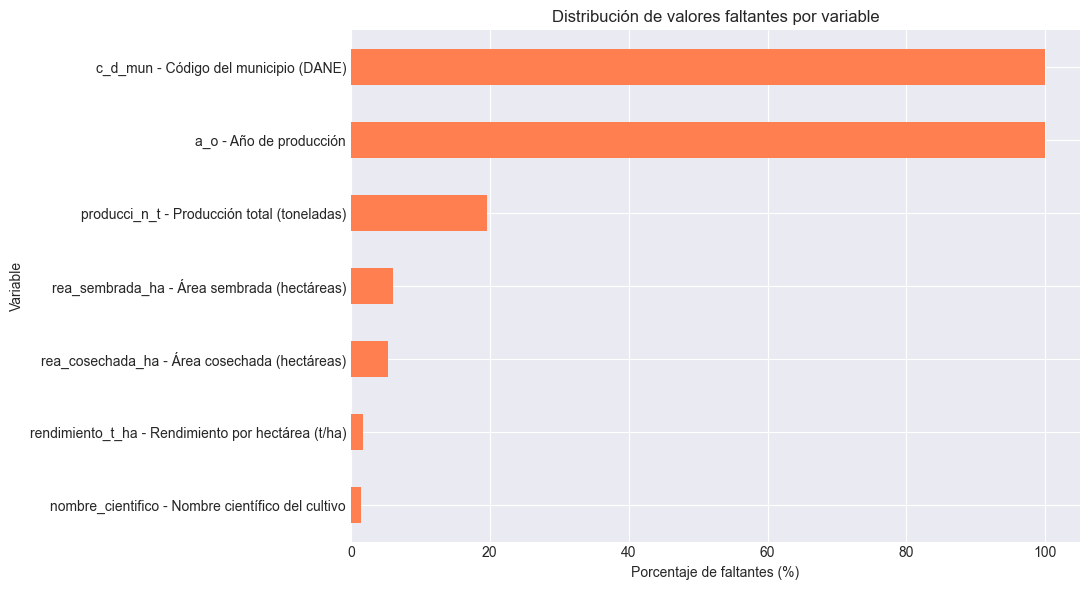


Conclusión de la gráfica de faltantes:
- c_d_mun: 100.0% de faltantes.
- a_o: 100.0% de faltantes.
- producci_n_t: 19.57% de faltantes.
- Priorizar imputación o tratamiento específico en las variables con mayor porcentaje de ausencia.


In [157]:
# Visualización del porcentaje de faltantes por columna + conclusión
if df is not None and len(df) > 0:
    missing_data_plot = pd.DataFrame({
        'columna': df.columns,
        'porcentaje_faltante': (df.isnull().sum() / len(df) * 100).round(2)
    })
    missing_data_plot = missing_data_plot[missing_data_plot['porcentaje_faltante'] > 0].sort_values('porcentaje_faltante')

    if len(missing_data_plot) > 0:
        missing_data_plot['etiqueta'] = missing_data_plot['columna'].apply(label_variable) if 'label_variable' in globals() else missing_data_plot['columna']

        fig, ax = plt.subplots(figsize=(11, 6))
        missing_data_plot.plot(
            kind='barh',
            x='etiqueta',
            y='porcentaje_faltante',
            ax=ax,
            color='coral',
            legend=False
        )
        ax.set_xlabel('Porcentaje de faltantes (%)')
        ax.set_ylabel('Variable')
        ax.set_title('Distribución de valores faltantes por variable')
        plt.tight_layout()
        plt.show()

        top_missing = missing_data_plot.sort_values('porcentaje_faltante', ascending=False).head(3)
        print('\nConclusión de la gráfica de faltantes:')
        for _, row in top_missing.iterrows():
            print(f"- {row['columna']}: {row['porcentaje_faltante']}% de faltantes.")
        print('- Priorizar imputación o tratamiento específico en las variables con mayor porcentaje de ausencia.')
    else:
        print('No hay faltantes para visualizar.')
        print('Conclusión: la completitud de datos es alta en todas las variables.')
else:
    print('No hay datos cargados.')

### Conclusión interpretativa de faltantes

La visualización de faltantes permite identificar con precisión qué variables requieren una estrategia de tratamiento prioritaria antes del modelado. En términos metodológicos, las columnas con mayor ausencia deben abordarse con imputación guiada por contexto agronómico o, si la pérdida es estructural, mediante exclusión justificada para evitar sesgos en entrenamiento y evaluación.

## 4. Distribuciones: diagnóstico estadístico base

In [158]:
# Estadísticos descriptivos para variables numéricas
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 0:
        print('Estadística descriptiva (variables numéricas):')
        print('=' * 100)
        display(df[numerical_cols].describe().T)
    else:
        print('No se encontraron columnas numéricas.')
else:
    print('No hay datos cargados.')

Estadística descriptiva (variables numéricas):


,count,mean,std,min,25%,50%,75%,max
c_d_dep,206068.0,40.322563,25.278662,5.00,17.0,41.0,68.00,99.0
c_d_mun,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a_o,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rea_sembrada_ha,193516.0,108.077342,179.394527,0.00,9.0,30.0,114.00,999.0
rea_cosechada_ha,195180.0,98.686879,172.849269,0.00,7.0,25.0,100.00,999.0
producci_n_t,165750.0,181.962057,227.895602,0.00,22.0,80.0,252.00,999.0
rendimiento_t_ha,202635.0,9.238820,14.888659,0.03,1.5,5.0,11.23,246.0


In [159]:
# Estadísticos para variables categóricas
if df is not None and len(df) > 0:
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    if len(categorical_cols) > 0:
        print('Resumen de variables categóricas:')
        print('=' * 100)
        for col in categorical_cols:
            print(f'\n{col}:')
            print(f'  Valores únicos: {df[col].nunique()}')
            print('  Valores más frecuentes:')
            print(df[col].value_counts().head())
    else:
        print('No se encontraron columnas categóricas.')
else:
    print('No hay datos cargados.')

Resumen de variables categóricas:

departamento:
  Valores únicos: 32
  Valores más frecuentes:
departamento
BOYACA             20576
ANTIOQUIA          18759
CUNDINAMARCA       17805
HUILA              15926
VALLE DEL CAUCA    15774
Name: count, dtype: int64

municipio:
  Valores únicos: 1018
  Valores más frecuentes:
municipio
BOLIVAR       1012
LA UNION       916
SAN PEDRO      915
BUENAVISTA     859
GUADALUPE      727
Name: count, dtype: int64

grupo_de_cultivo:
  Valores únicos: 13
  Valores más frecuentes:
grupo_de_cultivo
FRUTALES                 50236
CEREALES                 36045
HORTALIZAS               32032
TUBERCULOS Y PLATANOS    30664
LEGUMINOSAS              26368
Name: count, dtype: int64

subgrupo_de_cultivo:
  Valores únicos: 120
  Valores más frecuentes:
subgrupo_de_cultivo
MAIZ       24965
FRIJOL     14693
TOMATE      9654
YUCA        9488
PLATANO     9048
Name: count, dtype: int64

cultivo:
  Valores únicos: 223
  Valores más frecuentes:
cultivo
MAIZ       24965


## 4.1 Distribuciones numéricas, asimetría y necesidad de transformación

Esta sección examina la forma de las distribuciones numéricas para identificar asimetría, colas largas y posibles transformaciones antes de entrenar modelos. Se reportan histogramas por variable y se marcan las columnas con asimetría alta como candidatas a transformación.

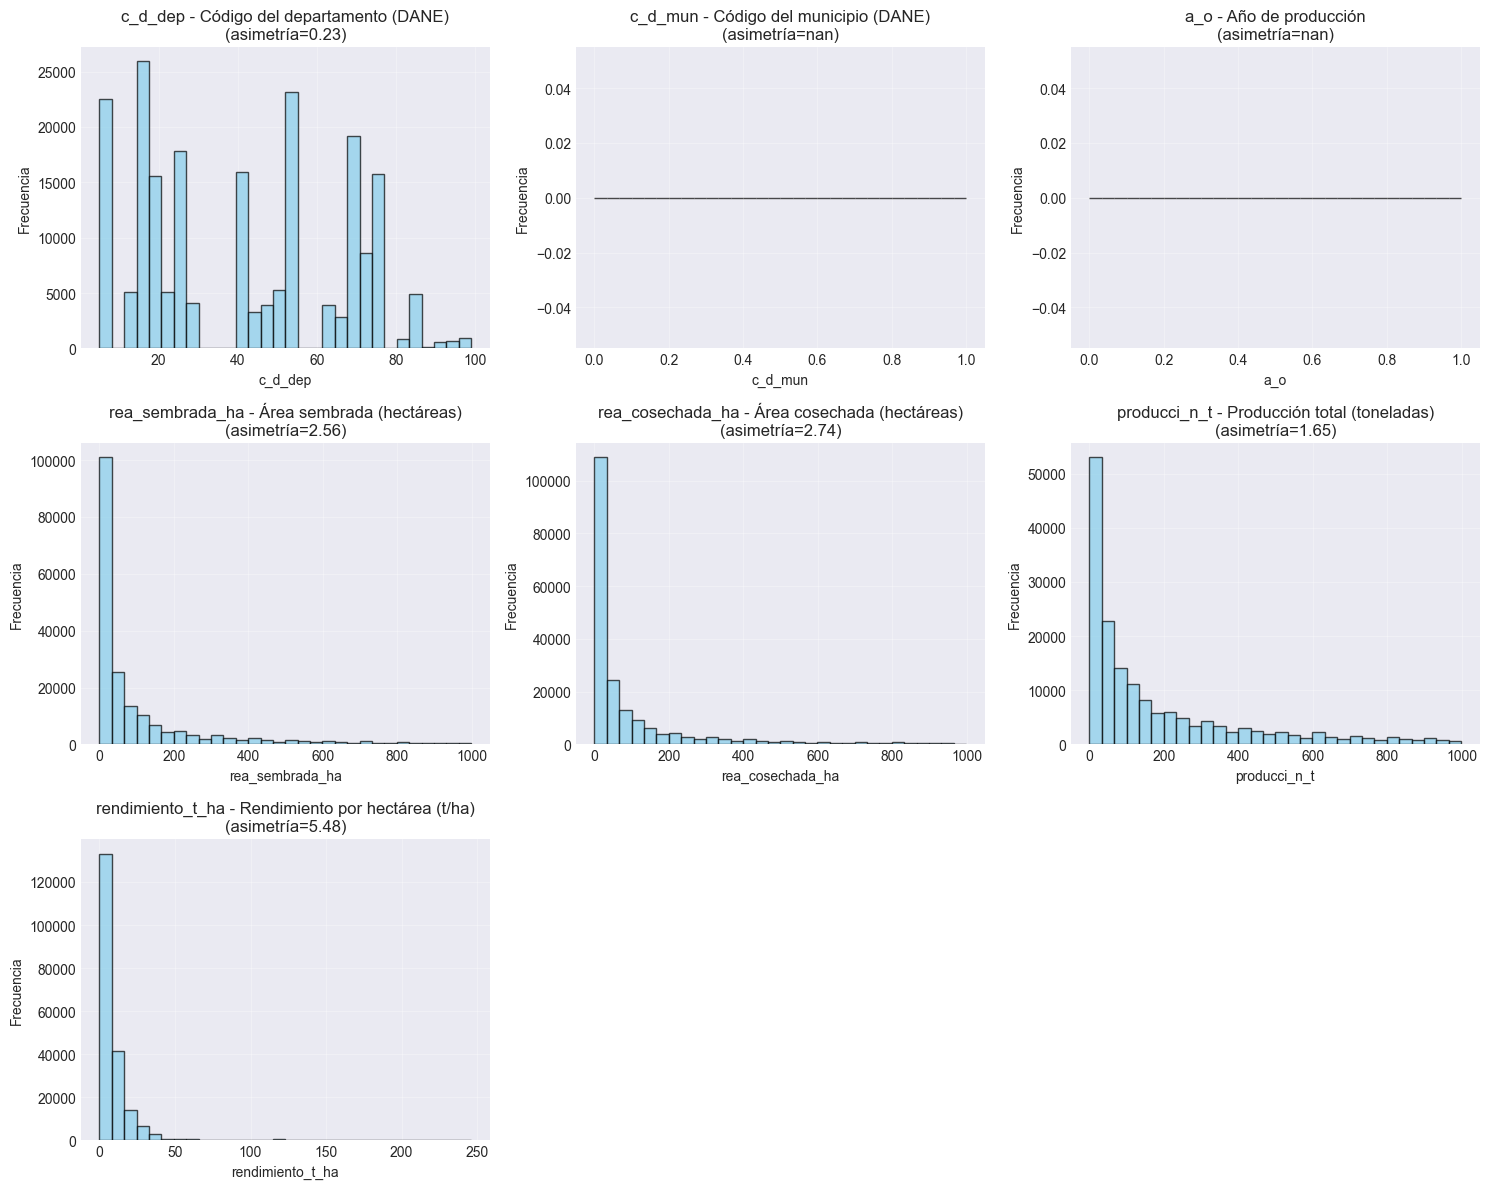


Conclusión de histogramas:
- Se observan distribuciones asimétricas en variables productivas, lo cual puede afectar modelos lineales y métricas basadas en media.
- Variables con asimetría alta (|skew| > 1):
  * rendimiento_t_ha (skew=5.48)
  * rea_cosechada_ha (skew=2.74)
  * rea_sembrada_ha (skew=2.56)
  * producci_n_t (skew=1.65)
- Recomendación: considerar transformaciones (log1p/Box-Cox/Yeo-Johnson) en estas columnas.


In [160]:
# Histogramas de variables numéricas + conclusión interpretativa
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 0:
        n_cols = len(numerical_cols)
        n_rows = (n_cols + 2) // 3

        fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
        axes = axes.flatten()

        skew_rows = []
        for idx, col in enumerate(numerical_cols):
            series = df[col].dropna()
            axes[idx].hist(series, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
            skew = series.skew()
            skew_rows.append({'columna': col, 'asimetria': skew})
            axes[idx].set_title(f"{label_variable(col) if 'label_variable' in globals() else col}\n(asimetría={skew:.2f})")
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frecuencia')
            axes[idx].grid(True, alpha=0.3)

        for idx in range(len(numerical_cols), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()

        skew_df = pd.DataFrame(skew_rows)
        high_skew = skew_df[skew_df['asimetria'].abs() > 1].sort_values('asimetria', key=lambda s: s.abs(), ascending=False)

        print('\nConclusión de histogramas:')
        if len(high_skew) > 0:
            print('- Se observan distribuciones asimétricas en variables productivas, lo cual puede afectar modelos lineales y métricas basadas en media.')
            print('- Variables con asimetría alta (|skew| > 1):')
            for _, row in high_skew.head(5).iterrows():
                print(f"  * {row['columna']} (skew={row['asimetria']:.2f})")
            print('- Recomendación: considerar transformaciones (log1p/Box-Cox/Yeo-Johnson) en estas columnas.')
        else:
            print('- Las distribuciones presentan asimetría moderada; no se requieren transformaciones intensivas de forma inmediata.')
    else:
        print('No hay columnas numéricas para visualizar.')
else:
    print('No hay datos cargados.')

### Conclusión interpretativa de histogramas

Las distribuciones numéricas evidencian heterogeneidad estructural entre observaciones territoriales y productivas. Cuando se observan asimetrías marcadas, es técnicamente recomendable aplicar transformaciones que estabilicen escala y varianza, con el fin de mejorar la robustez de modelos sensibles a colas largas y valores extremos.

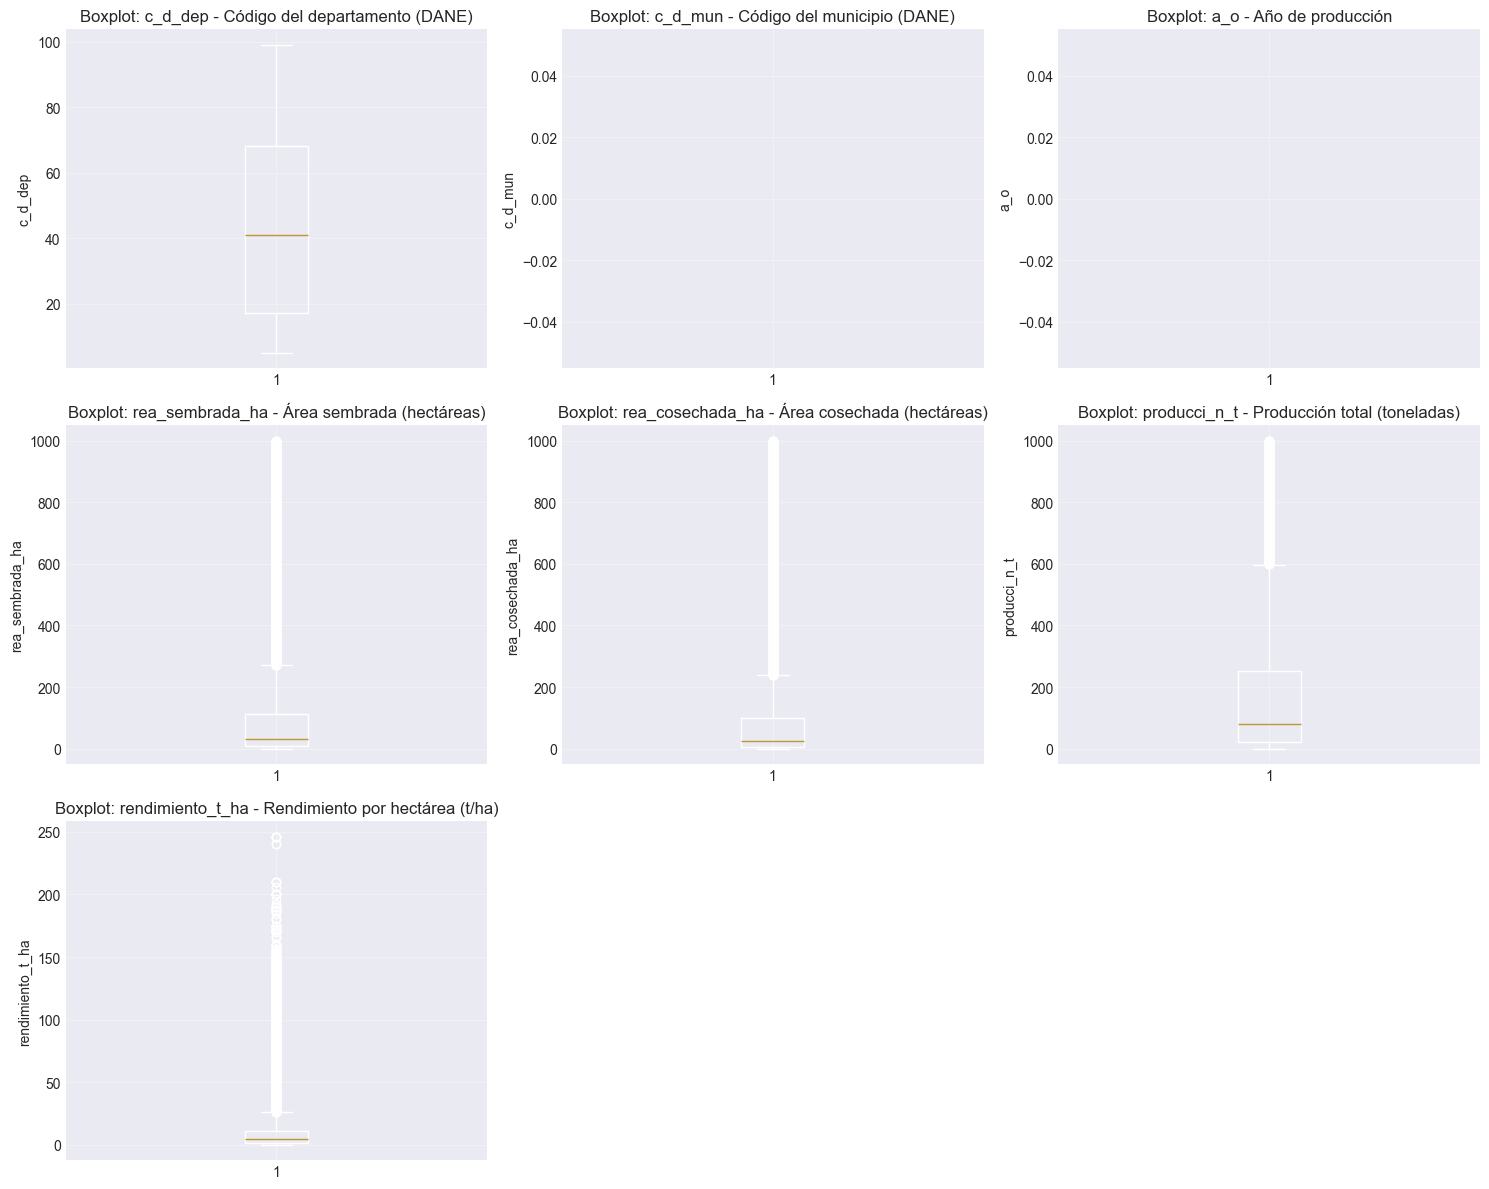


Conclusión de boxplots:
- La presencia de puntos fuera de los bigotes sugiere valores atípicos en varias variables numéricas.
- Este patrón es consistente con datos agroproductivos, donde existen municipios/cultivos con escalas de producción muy distintas.
- Se recomienda validar outliers antes del modelado para evitar sesgo en estimaciones sensibles a extremos.


In [161]:
# Boxplots para inspección visual de outliers + conclusión
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 0:
        n_cols = len(numerical_cols)
        n_rows = (n_cols + 2) // 3

        fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
        axes = axes.flatten()

        for idx, col in enumerate(numerical_cols):
            axes[idx].boxplot(df[col].dropna())
            axes[idx].set_title(f"Boxplot: {label_variable(col) if 'label_variable' in globals() else col}")
            axes[idx].set_ylabel(col)
            axes[idx].grid(True, alpha=0.3)

        for idx in range(len(numerical_cols), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()

        print('\nConclusión de boxplots:')
        print('- La presencia de puntos fuera de los bigotes sugiere valores atípicos en varias variables numéricas.')
        print('- Este patrón es consistente con datos agroproductivos, donde existen municipios/cultivos con escalas de producción muy distintas.')
        print('- Se recomienda validar outliers antes del modelado para evitar sesgo en estimaciones sensibles a extremos.')
    else:
        print('No hay columnas numéricas para visualizar.')
else:
    print('No hay datos cargados.')

### Conclusión interpretativa de boxplots

La presencia de observaciones fuera de los bigotes confirma que el conjunto contiene valores atípicos en variables de escala productiva. Este resultado es consistente con la dinámica agropecuaria real; no obstante, antes del entrenamiento conviene definir un criterio explícito para distinguir entre extremos plausibles y posibles registros anómalos.

## 5. Relación entre variables (correlación, redundancia y multicolinealidad)

La matriz de correlación permite detectar variables con información redundante. En esta sección se listan pares con correlación alta y se discute su posible impacto en estabilidad, interpretación y selección de variables.

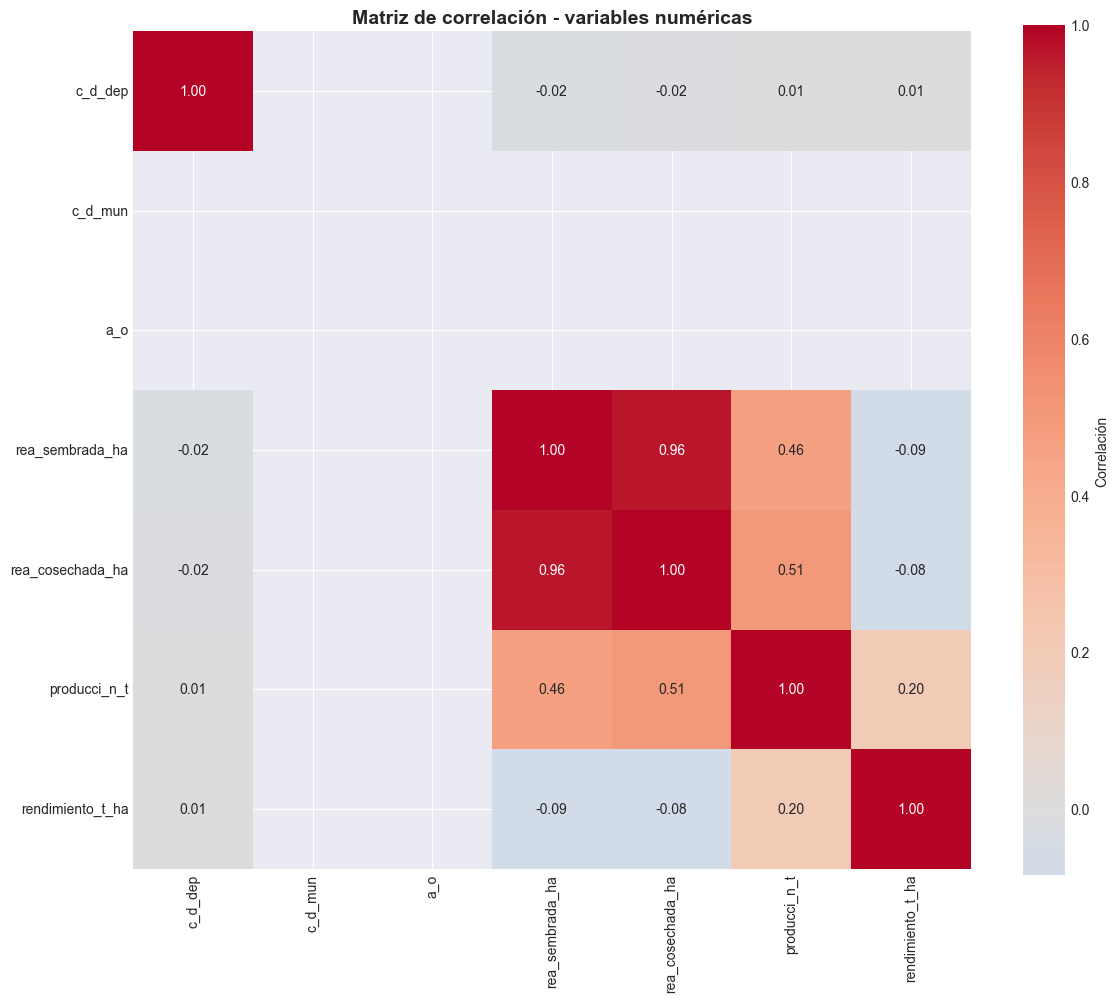


Pares altamente correlacionados (|correlación| > 0.7):


,Variable_1,Variable_2,Descripcion_1,Descripcion_2,Correlacion
0,rea_sembrada_ha,rea_cosechada_ha,Área sembrada (hectáreas),Área cosechada (hectáreas),0.964441



Conclusión de correlación:
- Existen pares con correlación alta, lo que indica posible redundancia de información.
- Para modelado lineal se recomienda evaluar eliminación de variables colineales o reducción de dimensionalidad.


In [162]:
# Matriz de correlación y pares redundantes + conclusión
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 1:
        corr_matrix = df[numerical_cols].corr()

        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax,
            cbar_kws={'label': 'Correlación'}
        )
        ax.set_title('Matriz de correlación - variables numéricas', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print('\nPares altamente correlacionados (|correlación| > 0.7):')
        print('=' * 80)
        corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i + 1, len(corr_matrix.columns)):
                corr_val = corr_matrix.iloc[i, j]
                if abs(corr_val) > 0.7:
                    v1 = corr_matrix.columns[i]
                    v2 = corr_matrix.columns[j]
                    corr_pairs.append({
                        'Variable_1': v1,
                        'Variable_2': v2,
                        'Descripcion_1': description_map.get(v1, 'sin descripción') if 'description_map' in globals() else 'sin descripción',
                        'Descripcion_2': description_map.get(v2, 'sin descripción') if 'description_map' in globals() else 'sin descripción',
                        'Correlacion': corr_val
                    })

        if corr_pairs:
            corr_df = pd.DataFrame(corr_pairs)
            display(corr_df.sort_values('Correlacion', key=lambda s: s.abs(), ascending=False))
            print('\nConclusión de correlación:')
            print('- Existen pares con correlación alta, lo que indica posible redundancia de información.')
            print('- Para modelado lineal se recomienda evaluar eliminación de variables colineales o reducción de dimensionalidad.')
        else:
            print('No se encontraron pares altamente correlacionados.')
            print('Conclusión: no se observa multicolinealidad fuerte entre las variables numéricas evaluadas.')
    else:
        print('No hay suficientes variables numéricas para análisis de correlación.')
else:
    print('No hay datos cargados.')

### Conclusión interpretativa de correlación

La matriz de correlación permite identificar pares de variables con comportamiento redundante, especialmente entre magnitudes de área y producción. Este hallazgo orienta decisiones de selección de variables, control de multicolinealidad y elección de modelos más estables e interpretables.

## 5.1 Estructura de variables categóricas

Como complemento al análisis de correlación numérica, se revisa la composición de categorías para identificar concentración de clases y posibles sesgos de representación.

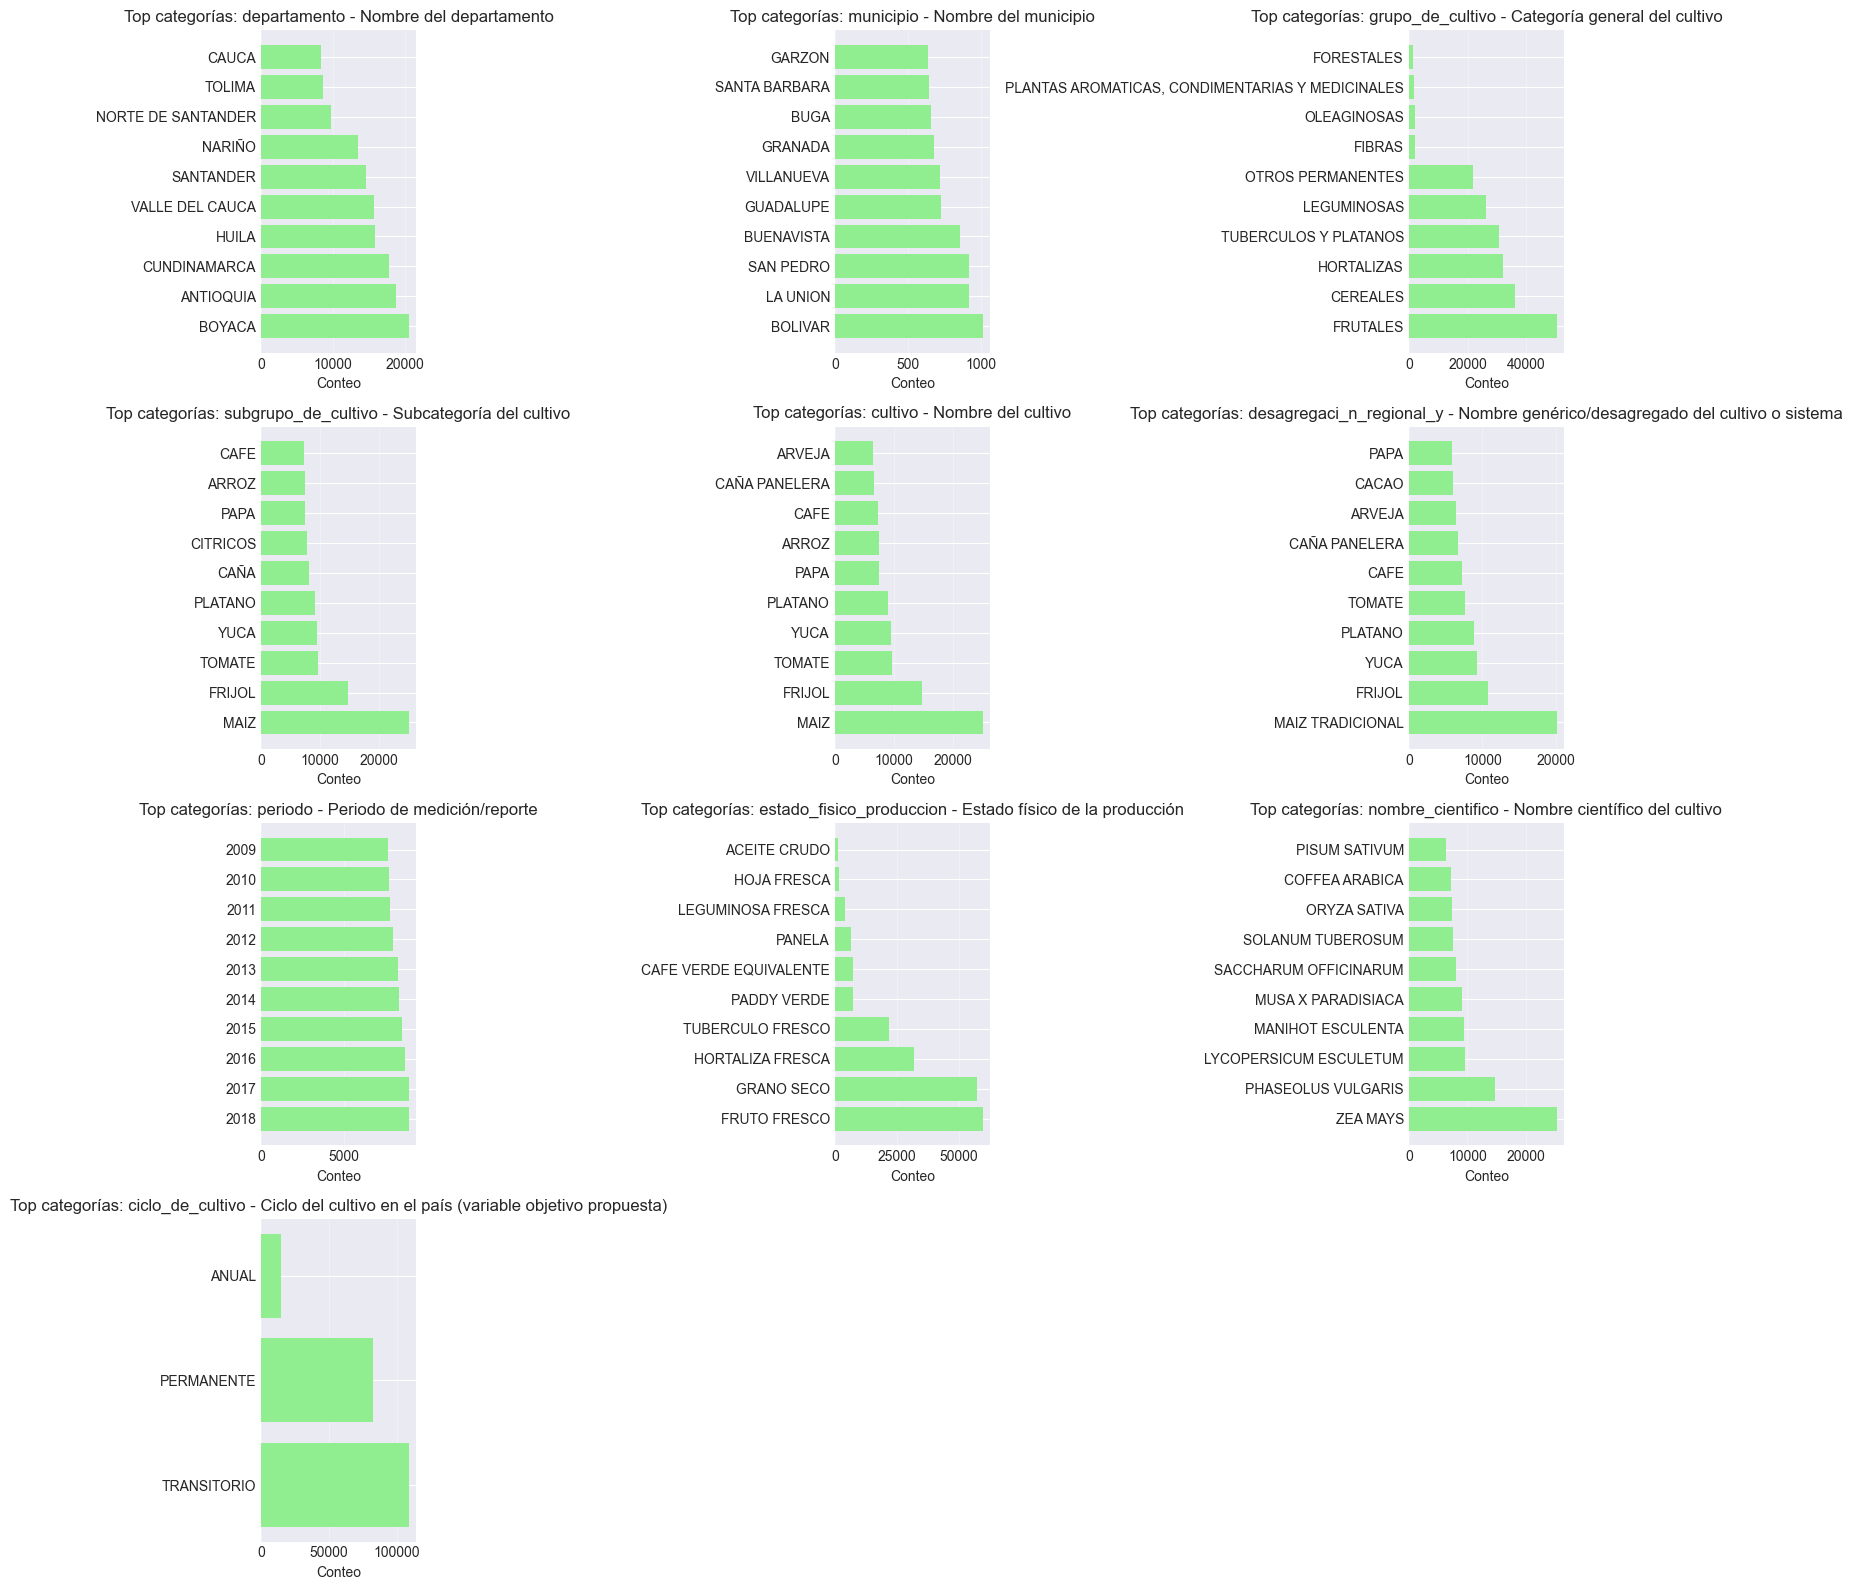


Conclusión de variables categóricas:
- Se observa concentración de frecuencia en pocas categorías para varias variables.
- Este comportamiento puede generar sesgo por dominancia de categorías mayoritarias.
- Recomendación: usar codificación robusta y, cuando aplique, agrupar categorías raras.


In [163]:
# Distribución de categorías por variable + conclusión
if df is not None and len(df) > 0:
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    if len(categorical_cols) > 0:
        n_cat_cols = len(categorical_cols)
        n_rows = (n_cat_cols + 2) // 3

        fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
        axes = axes.flatten()

        for idx, col in enumerate(categorical_cols):
            top_values = df[col].value_counts().head(10)
            axes[idx].barh(range(len(top_values)), top_values.values, color='lightgreen')
            axes[idx].set_yticks(range(len(top_values)))
            axes[idx].set_yticklabels(top_values.index)
            axes[idx].set_title(f"Top categorías: {label_variable(col) if 'label_variable' in globals() else col}")
            axes[idx].set_xlabel('Conteo')
            axes[idx].grid(True, alpha=0.3, axis='x')

        for idx in range(len(categorical_cols), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()

        print('\nConclusión de variables categóricas:')
        print('- Se observa concentración de frecuencia en pocas categorías para varias variables.')
        print('- Este comportamiento puede generar sesgo por dominancia de categorías mayoritarias.')
        print('- Recomendación: usar codificación robusta y, cuando aplique, agrupar categorías raras.')
    else:
        print('No se encontraron columnas categóricas.')
else:
    print('No hay datos cargados.')

### Conclusión interpretativa de variables categóricas

La concentración de frecuencias en categorías dominantes sugiere distribución no uniforme de clases en varias variables cualitativas. Para modelado, este patrón justifica estrategias de codificación cuidadosa y, cuando sea pertinente, agrupación de categorías de baja representatividad para reducir ruido estadístico.

## 5.2 Detección de outliers y estabilidad de variables

Se cuantifican valores atípicos mediante IQR para estimar su impacto potencial en entrenamiento y definir si se requiere winsorización, transformación o modelado robusto.

In [164]:
# Cuantificación de outliers por IQR + conclusión
if df is not None and len(df) > 0:
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numerical_cols) > 0:
        outlier_summary = []

        for col in numerical_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

            if len(outliers) > 0:
                outlier_summary.append({
                    'columna': col,
                    'descripcion': description_map.get(col, 'sin descripción') if 'description_map' in globals() else 'sin descripción',
                    'cantidad_outliers': len(outliers),
                    'porcentaje_outliers': round((len(outliers) / len(df)) * 100, 2),
                    'limite_inferior': lower_bound,
                    'limite_superior': upper_bound
                })

        if outlier_summary:
            outlier_df = pd.DataFrame(outlier_summary).sort_values('porcentaje_outliers', ascending=False)
            print('Resumen de outliers (método IQR):')
            print('=' * 100)
            display(outlier_df)

            print('\nConclusión de outliers:')
            top_out = outlier_df.head(3)
            for _, row in top_out.iterrows():
                print(f"- {row['columna']} ({row['descripcion']}): {row['porcentaje_outliers']}% de valores atípicos.")
            print('- Se recomienda validar si estos extremos representan variabilidad real o registros anómalos.')
        else:
            print('No se detectaron outliers con el método IQR.')
            print('Conclusión: las variables numéricas presentan estabilidad respecto a la regla IQR.')
    else:
        print('No hay variables numéricas para detección de outliers.')
else:
    print('No hay datos cargados.')

Resumen de outliers (método IQR):


,columna,descripcion,cantidad_outliers,porcentaje_outliers,limite_inferior,limite_superior
1,rea_cosechada_ha,Área cosechada (hectáreas),25130,12.20,-132.500,239.500
0,rea_sembrada_ha,Área sembrada (hectáreas),24376,11.83,-148.500,271.500
2,producci_n_t,Producción total (toneladas),14118,6.85,-323.000,597.000
3,rendimiento_t_ha,Rendimiento por hectárea (t/ha),11324,5.50,-13.095,25.825



Conclusión de outliers:
- rea_cosechada_ha (Área cosechada (hectáreas)): 12.2% de valores atípicos.
- rea_sembrada_ha (Área sembrada (hectáreas)): 11.83% de valores atípicos.
- producci_n_t (Producción total (toneladas)): 6.85% de valores atípicos.
- Se recomienda validar si estos extremos representan variabilidad real o registros anómalos.


### Conclusión interpretativa de outliers por IQR

La cuantificación de atípicos confirma que ciertas variables acumulan proporciones relevantes de valores extremos. En términos de preparación de datos, se recomienda documentar una política de tratamiento consistente (transformación, winsorización o modelado robusto) alineada con la naturaleza productiva del fenómeno analizado.

## 6. Relación con la variable objetivo

Esta sección evalúa capacidad de separación entre clases y relevancia predictiva de las variables numéricas seleccionadas.

Evaluación de separabilidad para clasificación:
- Clases con al menos 10 registros: 3
Top variables con mayor separabilidad entre clases (ANOVA):


,variable,descripcion,f_stat,p_value
3,producci_n_t,Producción total (toneladas),985.463001,0.000000e+00
1,rea_sembrada_ha,Área sembrada (hectáreas),811.314907,0.000000e+00
2,rea_cosechada_ha,Área cosechada (hectáreas),468.702868,8.554472e-204
0,c_d_dep,Código del departamento (DANE),174.181608,2.616729e-76
4,rendimiento_t_ha,Rendimiento por hectárea (t/ha),1.916242,1.471616e-01


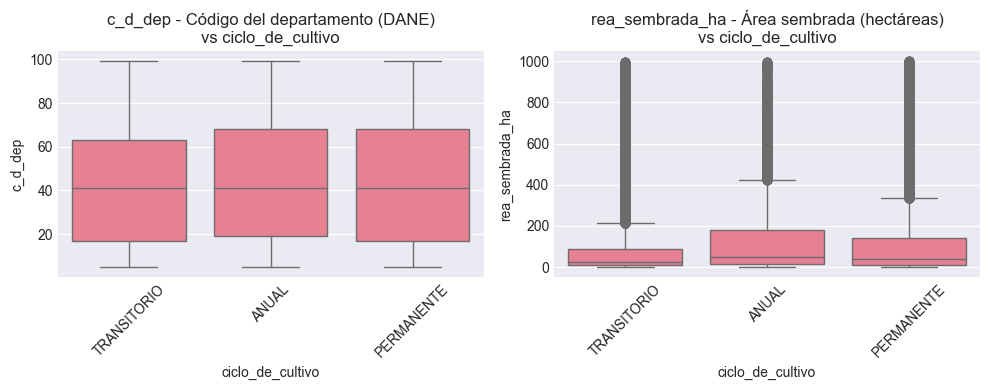


Variables numéricas potencialmente inútiles (varianza nula):
['c_d_mun', 'a_o']

Conclusión de relación con objetivo:
- La variable más discriminante fue producci_n_t (Producción total (toneladas)) con F=985.46 y p=0.
- Existe señal estadística para clasificación, por lo que la variable objetivo es utilizable para modelado supervisado.


In [167]:
# Separabilidad y utilidad de variables respecto al objetivo + conclusión
if df is not None and len(df) > 0 and TARGET_COLUMN in df.columns:
    target = TARGET_COLUMN
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target]

    if len(numeric_cols) == 0:
        print('No hay variables numéricas para evaluar separabilidad.')
    else:
        y = df[target]
        y_non_null = y.dropna()
        n_unique = y_non_null.nunique()
        is_classification = (y.dtype == 'object') or (n_unique <= 20)
        sep_df = pd.DataFrame()

        if not is_classification and pd.api.types.is_numeric_dtype(df[target]):
            corr_target = df[numeric_cols + [target]].corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
            print('Variables numéricas más relacionadas con el objetivo (|correlación|):')
            display(corr_target.to_frame('corr_abs_con_objetivo').head(10))
        else:
            print('Evaluación de separabilidad para clasificación:')
            class_counts = y.value_counts(dropna=True)
            valid_classes = class_counts[class_counts >= 10].index.tolist()
            print(f'- Clases con al menos 10 registros: {len(valid_classes)}')

            separability_rows = []
            for col in numeric_cols:
                groups = [df.loc[df[target] == cls, col].dropna().values for cls in valid_classes]
                groups = [g for g in groups if len(g) >= 10]
                if len(groups) >= 2:
                    try:
                        f_stat, p_value = stats.f_oneway(*groups)
                        separability_rows.append({
                            'variable': col,
                            'descripcion': description_map.get(col, 'sin descripción') if 'description_map' in globals() else 'sin descripción',
                            'f_stat': float(f_stat),
                            'p_value': float(p_value)
                        })
                    except Exception:
                        pass

            if separability_rows:
                sep_df = pd.DataFrame(separability_rows).sort_values('f_stat', ascending=False)
                print('Top variables con mayor separabilidad entre clases (ANOVA):')
                display(sep_df.head(10))
            else:
                print('No fue posible calcular separabilidad robusta con las clases actuales.')

        # Graficar solo variables con datos válidos para evitar errores de boxplot
        candidate_vars = numeric_cols[:4] if len(numeric_cols) >= 4 else numeric_cols
        plottable_vars = []
        for col in candidate_vars:
            tmp = df[[target, col]].dropna()
            if tmp.empty:
                continue
            if tmp[target].nunique() >= 2 and tmp[col].nunique() > 1:
                plottable_vars.append(col)

        if plottable_vars:
            n = len(plottable_vars)
            fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
            if n == 1:
                axes = [axes]

            for i, col in enumerate(plottable_vars):
                tmp = df[[target, col]].dropna()
                sns.boxplot(data=tmp, x=target, y=col, ax=axes[i])
                axes[i].set_title(f"{label_variable(col) if 'label_variable' in globals() else col}\nvs {target}")
                axes[i].tick_params(axis='x', rotation=45)

            plt.tight_layout()
            plt.show()
        else:
            print('No hay variables con datos suficientes para boxplots por clase.')

        low_var = [c for c in numeric_cols if df[c].nunique(dropna=True) <= 1]
        if low_var:
            print('\nVariables numéricas potencialmente inútiles (varianza nula):')
            print(low_var)
        else:
            print('\nNo se detectaron variables numéricas con varianza nula.')

        print('\nConclusión de relación con objetivo:')
        if not sep_df.empty:
            best = sep_df.iloc[0]
            print(f"- La variable más discriminante fue {best['variable']} ({best['descripcion']}) con F={best['f_stat']:.2f} y p={best['p_value']:.4g}.")
            print('- Existe señal estadística para clasificación, por lo que la variable objetivo es utilizable para modelado supervisado.')
        else:
            print('- La evidencia de separabilidad es limitada con la configuración actual; conviene ampliar ingeniería de variables.')
else:
    print('No se puede evaluar relación con objetivo: valida que TARGET_COLUMN esté definido y exista.')

### Conclusión interpretativa de relación con la variable objetivo

El análisis de separabilidad aporta evidencia sobre qué variables numéricas diferencian mejor las clases de la variable objetivo. Este resultado respalda la viabilidad del enfoque supervisado y ofrece una base técnica para priorizar atributos en el diseño del pipeline de entrenamiento.

## 7. Balance entre clases e implicaciones

Se analiza la distribución de la variable objetivo para anticipar riesgos de sesgo y definir métricas de evaluación adecuadas.

,clase,conteo,porcentaje
0,PERMANENTE,4342,86.84
1,ANUAL,435,8.70
2,TRANSITORIO,223,4.46


Ratio clase mayoritaria/minoritaria: 19.47


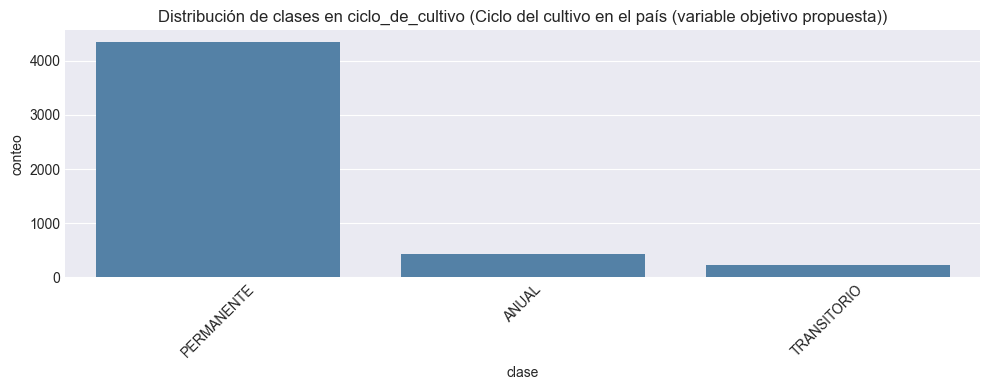


Implicaciones para modelado:
- Existe desbalance relevante; usar partición estratificada.
- Priorizar métricas robustas: F1 macro, balanced accuracy, ROC-AUC por clase.
- Evaluar remuestreo (SMOTE/undersampling) o ponderación de clases.

Conclusión de la gráfica de balance:
- La clase dominante es 'PERMANENTE' con 86.84% del total.
- Este comportamiento debe considerarse en la estrategia de entrenamiento y evaluación final.


In [ ]:
# Análisis de balance de clases + conclusión
if df is not None and len(df) > 0 and TARGET_COLUMN in df.columns:
    y = df[TARGET_COLUMN].dropna()
    is_classification = (y.dtype == 'object') or (y.nunique() <= 20)

    if is_classification:
        class_dist = y.value_counts().to_frame('conteo').reset_index()
        class_dist.columns = ['clase', 'conteo']
        class_dist['porcentaje'] = (class_dist['conteo'] / class_dist['conteo'].sum() * 100).round(2)
        display(class_dist)

        ratio = class_dist['conteo'].max() / class_dist['conteo'].min()
        print(f'Ratio clase mayoritaria/minoritaria: {ratio:.2f}')

        plt.figure(figsize=(10, 4))
        sns.barplot(data=class_dist, x='clase', y='conteo', color='steelblue')
        plt.title(f'Distribución de clases en {TARGET_COLUMN} ({description_map.get(TARGET_COLUMN, "sin descripción") if "description_map" in globals() else ""})')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        print('\nImplicaciones para modelado:')
        if ratio >= 3:
            print('- Existe desbalance relevante; usar partición estratificada.')
            print('- Priorizar métricas robustas: F1 macro, balanced accuracy, ROC-AUC por clase.')
            print('- Evaluar remuestreo (SMOTE/undersampling) o ponderación de clases.')
        else:
            print('- El balance es razonable para comenzar con modelos base.')
            print('- Mantener validación estratificada y monitorear métricas por clase.')

        print('\nConclusión de la gráfica de balance:')
        dominant = class_dist.iloc[0]
        print(f"- La clase dominante es '{dominant['clase']}' con {dominant['porcentaje']}% del total.")
        print('- Este comportamiento debe considerarse en la estrategia de entrenamiento y evaluación final.')
    else:
        print('La variable objetivo parece de regresión; no aplica balance de clases.')
else:
    print('No se puede analizar balance: valida que TARGET_COLUMN esté definido y exista.')

### Conclusión interpretativa de balance de clases

La distribución de clases debe evaluarse como un factor crítico de validez del modelo. Cuando existe desbalance, la evaluación no debe centrarse únicamente en exactitud global, sino incorporar métricas por clase y validación estratificada para evitar conclusiones optimistas sobre desempeño real.

## 8. Conclusiones y preparación del dataset para entrenamiento

### Síntesis técnica de resultados

El análisis confirmó que el conjunto contiene volumen y estructura suficientes para el objetivo del curso. Tras la estandarización de tipos se consolidó un bloque numérico robusto y se identificó una variable objetivo de clasificación con tres clases, lo que permite construir un flujo de modelado supervisado coherente.

En calidad de datos, los hallazgos principales se concentraron en faltantes de `rendimiento_t_ha` y en un faltante marginal de `municipio`, sin evidencia de duplicados exactos en la muestra evaluada. Este comportamiento sugiere que el esfuerzo de limpieza debe priorizar imputación o tratamiento específico de variables productivas con datos incompletos.

Las distribuciones y el análisis de outliers evidenciaron asimetrías pronunciadas en variables de área y producción, fenómeno esperable en datos agrícolas y relevante para la selección de transformaciones. En paralelo, la matriz de correlación mostró pares con alta asociación, por lo que se recomienda revisar redundancia antes del entrenamiento final.

La evaluación de relación con la variable objetivo y el análisis de balance de clases mostraron señal predictiva útil, pero también desbalance importante entre categorías. En consecuencia, la estrategia de validación y métricas debe enfocarse en desempeño por clase y no solo en exactitud global.

En términos metodológicos, el dataset queda apto para entrenamiento siempre que se mantenga el preprocesamiento documentado: tipificación numérica, tratamiento de faltantes, manejo de outliers y control explícito del desbalance.